# Insights — exploration scratchpad

Goal: eyeball the data before deciding which event hypotheses survive into the Insights tab.

Hypotheses to look at:
- COVID lockdown (spring 2020) — suppression of overall volume
- George Floyd unrest (late May / early June 2020) — short sharp spike, then settle
- Laquan McDonald video release (Nov 2015) — arrest **rate** break, not volume
- Polar vortex / blizzards — short troughs in winter daily volume
- Chicago **municipal** election windows under an incumbent mayor

Source: the local `chicago_crimes.csv` mirror (1.9 GB, gitignored). Going through pandas is faster and more interactive than paginating Socrata for 8.5M rows. The Socrata script in `scripts/fetch_and_build.py` remains the production source — this notebook is just a scratchpad.

**All event dates in this notebook are placeholders. Verify before publishing anything.**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

CSV_PATH = Path('..') / 'chicago_crimes.csv'
CSV_PATH.resolve()

PosixPath('/home/julienerbland/Documents/EPFL/Master/MA2/Data Viz/Projet/Crimiviz/chicago_crimes.csv')

## Load

Only the columns we need for these questions. `Date` parsed up-front, dtypes minimised.

In [2]:
usecols = ['Date', 'Primary Type', 'Arrest', 'Community Area', 'Location Description']
dtype = {
    'Primary Type': 'category',
    'Location Description': 'category',
    'Arrest': 'bool',
    'Community Area': 'float32',
}

df = pd.read_csv(
    CSV_PATH,
    usecols=usecols,
    dtype=dtype,
    parse_dates=['Date'],
    date_format='%m/%d/%Y %I:%M:%S %p',
)
df = df.rename(columns={
    'Date': 'date',
    'Primary Type': 'type',
    'Arrest': 'arrest',
    'Community Area': 'ca',
    'Location Description': 'location',
})
df = df.sort_values('date').reset_index(drop=True)
df['day'] = df['date'].dt.normalize()
print(f'{len(df):,} rows')
print(f'range: {df.date.min()}  →  {df.date.max()}')
df.head()

8,500,901 rows
range: 2001-01-01 00:00:00  →  2026-02-16 00:00:00


,date,type,location,arrest,ca,day
0,2001-01-01,THEFT,RESIDENCE,False,NaN,2001-01-01
1,2001-01-01,CRIMINAL DAMAGE,APARTMENT,False,NaN,2001-01-01
2,2001-01-01,DECEPTIVE PRACTICE,OTHER,False,1.0,2001-01-01
3,2001-01-01,SEX OFFENSE,CHURCH/SYNAGOGUE/PLACE OF WORSHIP,False,29.0,2001-01-01
4,2001-01-01,DECEPTIVE PRACTICE,AIRPORT/AIRCRAFT,True,76.0,2001-01-01


## 1. Long trend — daily volume, 2001 → today

Look for: COVID dip, secular decline, any sharp ceiling/floor moves.

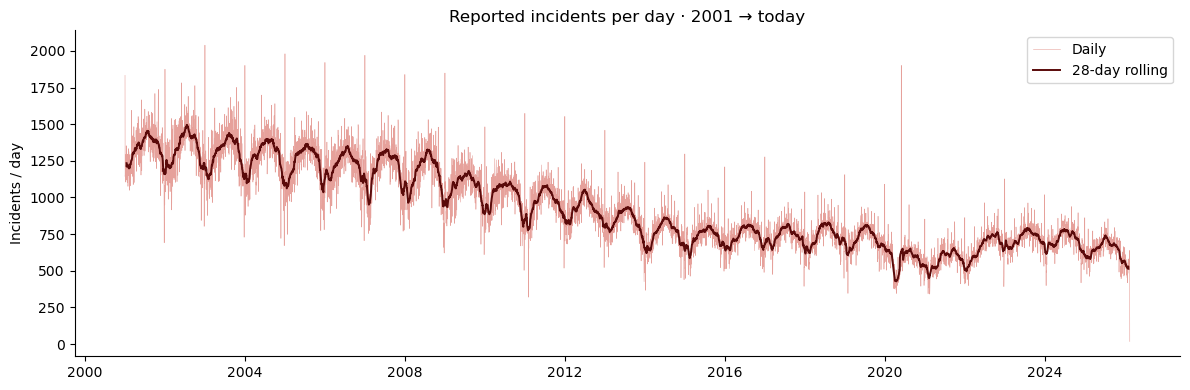

In [3]:
daily = df.groupby('day').size().rename('n').to_frame()
daily['n_7d'] = daily['n'].rolling(7, center=True).mean()
daily['n_28d'] = daily['n'].rolling(28, center=True).mean()

fig, ax = plt.subplots()
ax.plot(daily.index, daily['n'], lw=0.4, color='#c93023', alpha=0.45, label='Daily')
ax.plot(daily.index, daily['n_28d'], lw=1.4, color='#5a0a0a', label='28-day rolling')
ax.set_title('Reported incidents per day · 2001 → today')
ax.set_ylabel('Incidents / day')
ax.legend()
plt.tight_layout()

## 2. COVID lockdown — volume suppression

Spring 2020 lockdown drop, isolated from the Floyd spike (which gets its own section below).

Hypothesis: a sharp, multi-week suppression in spring 2020 that 2018 and 2019 did not show.

Event markers (**verify**):
- 2020-03-21 — Illinois "stay-at-home" order took effect
- approx lockdown window: 2020-03-21 → 2020-05-01

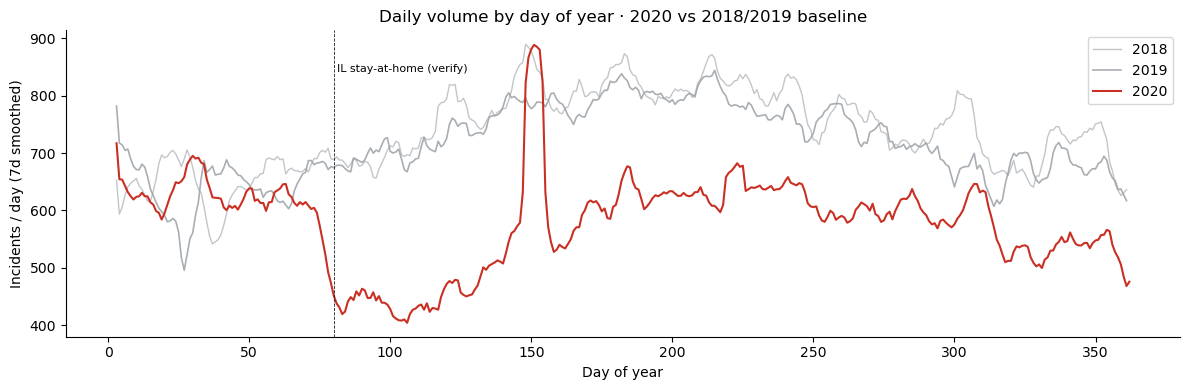

In [4]:
def to_doy(idx, year):
    return (idx - pd.Timestamp(f'{year}-01-01')).days

fig, ax = plt.subplots()
for y, color, alpha, lw in [(2018, '#9aa0a6', 0.6, 1.0),
                            (2019, '#9aa0a6', 0.85, 1.2),
                            (2020, '#c93023', 1.0, 1.5)]:
    w = daily.loc[f'{y}-01-01':f'{y}-12-31'].copy()
    w['doy'] = to_doy(w.index, y)
    smooth = w['n'].rolling(7, center=True).mean()
    ax.plot(w['doy'], smooth, color=color, alpha=alpha, lw=lw, label=str(y))
stay_home_doy = (pd.Timestamp('2020-03-21') - pd.Timestamp('2020-01-01')).days
ax.axvline(stay_home_doy, color='#1a1a1a', lw=0.6, ls='--')
ax.text(stay_home_doy + 1, ax.get_ylim()[1] * 0.92, 'IL stay-at-home (verify)', fontsize=8)
ax.set_xlabel('Day of year')
ax.set_ylabel('Incidents / day (7d smoothed)')
ax.set_title('Daily volume by day of year · 2020 vs 2018/2019 baseline')
ax.legend()
plt.tight_layout()

In [5]:
# Quantify the lockdown trough vs same calendar window in 2018+2019.
lockdown_start, lockdown_end = '03-21', '05-01'

def slice_window(year):
    return daily.loc[f'{year}-{lockdown_start}':f'{year}-{lockdown_end}']['n']

actual_2020 = slice_window(2020).mean()
baseline = pd.concat([slice_window(2018), slice_window(2019)]).mean()
print(f'Lockdown calendar window: {lockdown_start} → {lockdown_end}')
print(f'  2020 mean daily volume          : {actual_2020:,.0f}')
print(f'  2018+2019 baseline mean         : {baseline:,.0f}')
print(f'  Deviation                       : {(actual_2020 - baseline) / baseline * 100:+.1f}%')

Lockdown calendar window: 03-21 → 05-01
  2020 mean daily volume          : 436
  2018+2019 baseline mean         : 703
  Deviation                       : -38.0%


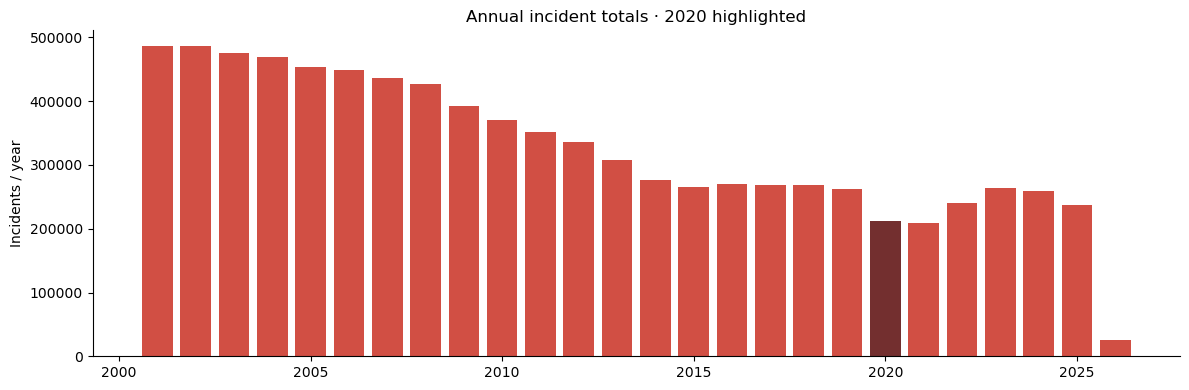

In [6]:
# Long-run context: where does 2020 sit relative to every other year?
yearly = df.groupby(df['date'].dt.year).size()
fig, ax = plt.subplots()
colors = ['#5a0a0a' if y == 2020 else '#c93023' for y in yearly.index]
ax.bar(yearly.index, yearly.values, color=colors, alpha=0.85)
ax.set_title('Annual incident totals · 2020 highlighted')
ax.set_ylabel('Incidents / year')
plt.tight_layout()

**Verdict (fill in after running the cells above):**

Expect a clean multi-week dip in 2020 against the 2018/2019 baseline curve through April; both adjacent years should track each other and sit well above 2020 in the same weeks. If the quantify cell prints a deviation of roughly **−20% to −35%**, the story is real. The annual-totals plot should confirm 2020 as the deepest dip of the era.

**Likely keeper.** Probably a headline Insight given the size of the effect and the public memory of lockdown.

## 3. George Floyd unrest — short volume spike

Tight zoom on May 1 → June 30 2020, isolated from the lockdown story.

Event markers (**verify**):
- 2020-05-25 — Floyd killed in Minneapolis
- 2020-05-30 → 2020-06-07 — Chicago unrest peak

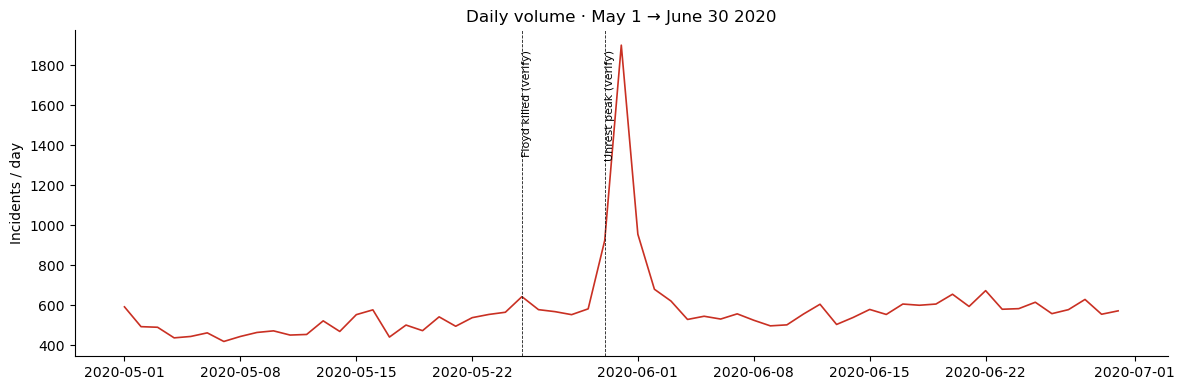

In [7]:
win = daily.loc['2020-05-01':'2020-06-30']
fig, ax = plt.subplots()
ax.plot(win.index, win['n'], lw=1.2, color='#c93023')
for d, label in [('2020-05-25', 'Floyd killed (verify)'),
                 ('2020-05-30', 'Unrest peak (verify)')]:
    ax.axvline(pd.Timestamp(d), color='#1a1a1a', lw=0.6, ls='--')
    ax.text(pd.Timestamp(d), ax.get_ylim()[1] * 0.95, '  ' + label,
            fontsize=8, rotation=90, va='top')
ax.set_title('Daily volume · May 1 → June 30 2020')
ax.set_ylabel('Incidents / day')
plt.tight_layout()

In [8]:
# Quantify the spike against the surrounding 2-week baselines.
spike_start, spike_end = pd.Timestamp('2020-05-29'), pd.Timestamp('2020-06-05')
pre_base = daily.loc['2020-05-11':'2020-05-24']['n'].mean()
post_base = daily.loc['2020-06-15':'2020-06-28']['n'].mean()

spike = daily.loc[spike_start:spike_end]['n']
peak_value = spike.max()
peak_day = spike.idxmax().date()
days_above_150 = (spike > pre_base * 1.5).sum()

print(f'Peak day in spike window           : {peak_day}, value {peak_value:,}')
print(f'Pre-spike baseline (May 11-24)     : {pre_base:,.0f}/day')
print(f'Post-spike baseline (Jun 15-28)    : {post_base:,.0f}/day')
print(f'Peak vs pre-baseline               : {(peak_value - pre_base) / pre_base * 100:+.1f}%')
print(f'Days in spike window above pre+50% : {days_above_150}')

Peak day in spike window           : 2020-05-31, value 1,901
Pre-spike baseline (May 11-24)     : 511/day
Post-spike baseline (Jun 15-28)    : 602/day
Peak vs pre-baseline               : +272.3%
Days in spike window above pre+50% : 3


In [9]:
# Which primary types drove the spike? Compare per-day rate in the spike
# vs the pre-spike 2 weeks (apples-to-apples, no calendar effect).
spike_df = df[(df['date'] >= spike_start) & (df['date'] < spike_end + pd.Timedelta(days=1))]
base_df = df[(df['date'] >= '2020-05-11') & (df['date'] < '2020-05-25')]

spike_days = (spike_end - spike_start).days + 1
base_days = 14

spike_per_day = spike_df['type'].value_counts() / spike_days
base_per_day = base_df['type'].value_counts() / base_days
comp = pd.concat([base_per_day, spike_per_day], axis=1, keys=['baseline', 'spike']).fillna(0)
comp['delta_per_day'] = comp['spike'] - comp['baseline']
comp['pct'] = (comp['spike'] / comp['baseline'].replace(0, np.nan) - 1) * 100
comp.sort_values('delta_per_day', ascending=False).head(10).round(1)

,baseline,spike,delta_per_day,pct
type,,,,
BURGLARY,18.4,133.6,115.2,625.1
CRIMINAL DAMAGE,68.4,139.4,71.0,103.9
PUBLIC PEACE VIOLATION,1.9,56.9,54.9,2849.1
BATTERY,108.4,130.4,21.9,20.2
MOTOR VEHICLE THEFT,24.0,40.1,16.1,67.2
ROBBERY,16.4,32.0,15.6,95.6
WEAPONS VIOLATION,26.7,42.2,15.5,58.2
ARSON,1.4,9.0,7.6,563.2
ASSAULT,46.9,53.2,6.4,13.6


**Verdict (fill in after running):**

Expect a 2–4 day spike with the largest absolute lift driven by property categories — `THEFT`, `CRIMINAL DAMAGE`, `BURGLARY`. If those three dominate the top of the delta table and the rest of the categories barely move, the unrest narrative holds. If person-on-person violence categories also surge, the story is more complex than a property-damage protest.

**Likely keeper as a short visual side panel**, not a headline. The whole effect probably lasts under a week.

## 4. Laquan McDonald — arrest-rate break (headline candidate)

Dashcam video released around 2015-11-24 (**verify**). The hypothesis is **not** about volume but about arrest **rate** — the share of incidents resulting in arrest.

Caveats to keep in the writeup:
- The Chicago consent decree (initiated 2017) drives reform in the same window
- Reporting practices and arrest definitions can drift over years
- Coincidence is not causation — this section quantifies the break, not its cause

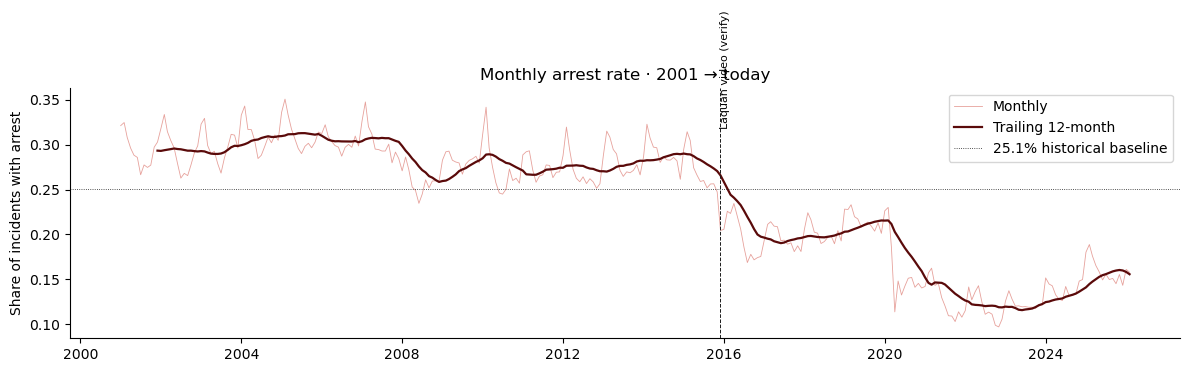

In [10]:
monthly = df.set_index('date').resample('MS').agg(
    n=('arrest', 'size'),
    arrests=('arrest', 'sum'),
)
monthly['arrest_rate'] = monthly['arrests'] / monthly['n']
monthly['rate_12m'] = monthly['arrest_rate'].rolling(12).mean()

fig, ax = plt.subplots()
ax.plot(monthly.index, monthly['arrest_rate'], lw=0.6, color='#c93023', alpha=0.45, label='Monthly')
ax.plot(monthly.index, monthly['rate_12m'], lw=1.6, color='#5a0a0a', label='Trailing 12-month')
ax.axhline(0.251, color='#1a1a1a', lw=0.6, ls=':', label='25.1% historical baseline')
ax.axvline(pd.Timestamp('2015-11-24'), color='#1a1a1a', lw=0.7, ls='--')
ax.text(pd.Timestamp('2015-11-24'), 0.45, '  Laquan video (verify)', fontsize=8, rotation=90, va='top')
ax.set_title('Monthly arrest rate · 2001 → today')
ax.set_ylabel('Share of incidents with arrest')
ax.legend()
plt.tight_layout()

In [11]:
# Quantify the break: 24 months before vs 24 months after the video release.
event = pd.Timestamp('2015-11-24')
pre = monthly.loc[event - pd.DateOffset(months=24):event - pd.Timedelta(days=1)]
post = monthly.loc[event:event + pd.DateOffset(months=24)]

pre_rate = pre['arrests'].sum() / pre['n'].sum()
post_rate = post['arrests'].sum() / post['n'].sum()
pre_vol = pre['n'].sum()
post_vol = post['n'].sum()

print(f'Pre-Laquan window  : {pre.index.min().date()} → {pre.index.max().date()}')
print(f'Post-Laquan window : {post.index.min().date()} → {post.index.max().date()}')
print()
print(f'Pre  : volume {pre_vol:>9,}   arrest rate {pre_rate*100:5.1f}%')
print(f'Post : volume {post_vol:>9,}   arrest rate {post_rate*100:5.1f}%')
print()
print(f'Volume change      : {(post_vol - pre_vol) / pre_vol * 100:+.1f}%')
print(f'Arrest-rate change : {(post_rate - pre_rate) * 100:+.1f} pp ({(post_rate / pre_rate - 1) * 100:+.1f}%)')

Pre-Laquan window  : 2013-12-01 → 2015-11-01
Post-Laquan window : 2015-12-01 → 2017-11-01

Pre  : volume   541,491   arrest rate  27.9%
Post : volume   539,271   arrest rate  19.7%

Volume change      : -0.4%
Arrest-rate change : -8.2 pp (-29.4%)


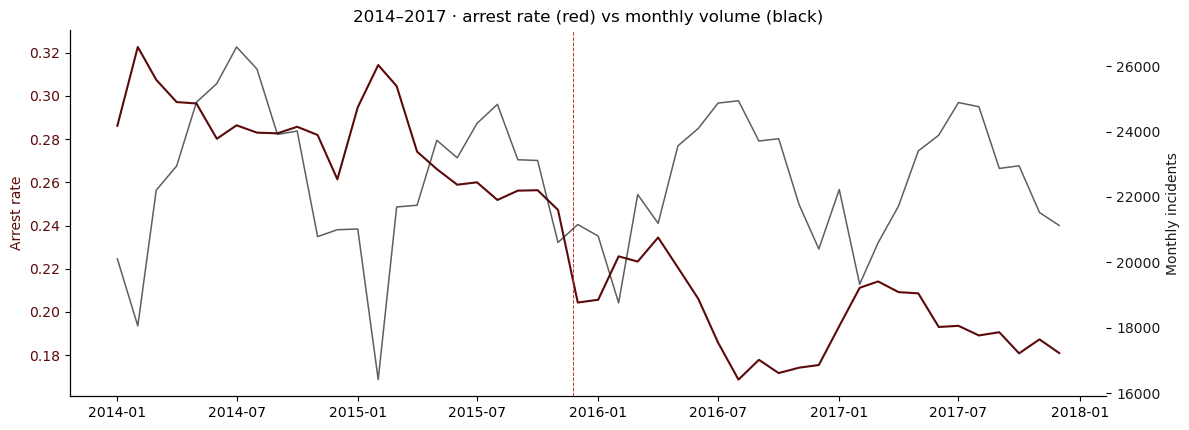

In [12]:
# Honesty check: plot arrest rate AND total volume on the same time axis
# so we can see they move independently. If both fall together, it's not
# specifically an arrest-rate story.
zoom = monthly.loc['2014-01-01':'2017-12-31']

fig, ax1 = plt.subplots(figsize=(12, 4.4))
ax1.plot(zoom.index, zoom['arrest_rate'], color='#5a0a0a', lw=1.5, label='Arrest rate (left)')
ax1.set_ylabel('Arrest rate', color='#5a0a0a')
ax1.tick_params(axis='y', labelcolor='#5a0a0a')

ax2 = ax1.twinx()
ax2.plot(zoom.index, zoom['n'], color='#1a1a1a', lw=1.1, alpha=0.7, label='Volume (right)')
ax2.set_ylabel('Monthly incidents', color='#1a1a1a')
ax2.tick_params(axis='y', labelcolor='#1a1a1a')

ax1.axvline(pd.Timestamp('2015-11-24'), color='#c93023', lw=0.7, ls='--')
ax1.set_title('2014–2017 · arrest rate (red) vs monthly volume (black)')
plt.tight_layout()

**Verdict (fill in after running):**

Expect volume roughly flat across 2014–2017 while arrest rate drops visibly through 2016. If the 24-month pre/post quantification cell shows volume within ±10% but arrest rate dropping by ≥5 percentage points, this is the **strongest single-event story in the dataset**.

Confounders to address in the writeup, not in the chart:
- 2017 DOJ consent decree initiated department-wide reform
- Officer attrition and shift-coverage changes through the same window
- Possible re-classification of arrest dispositions in CPD systems

**Headline Insight candidate.**

## 5. Blizzards & polar vortex — winter dips

Hypothesis: extreme cold suppresses outdoor-dependent crime for 1–3 days. Each event window overlaid with the same calendar slice from an adjacent normal year, so we see whether the dip is the event or just the season.

Event candidates (**verify all dates**):
- 2011-02-01 → 2011-02-03 — Groundhog Day blizzard (baseline: 2010 + 2012)
- 2014-01-06 → 2014-01-08 — polar vortex peak (baseline: 2013 + 2015) — **NOTE**: this window includes the Jan 1 spike, which is New Year's Eve, not weather
- 2019-01-30 → 2019-02-01 — Chicago polar vortex (baseline: 2018 + 2020)

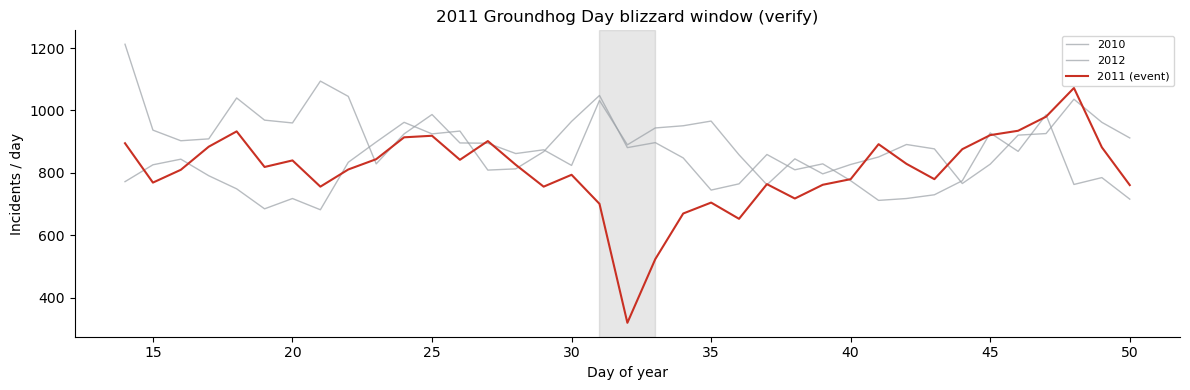

  Lowest day 2011 02-01→02-03: 320
  Same days, baseline years [2010, 2012]: 949
  Deviation: -66.3%


In [13]:
def window_with_doy(year, start_md, end_md):
    w = daily.loc[f'{year}-{start_md}':f'{year}-{end_md}'].copy()
    w['doy'] = (w.index - pd.Timestamp(f'{year}-01-01')).days
    return w

def doy_of(date_str):
    d = pd.Timestamp(date_str)
    return (d - pd.Timestamp(f'{d.year}-01-01')).days

def plot_event(event_year, baseline_years, event_start, event_end, win_start, win_end, title):
    fig, ax = plt.subplots()
    for y in baseline_years:
        w = window_with_doy(y, win_start, win_end)
        ax.plot(w['doy'], w['n'], color='#9aa0a6', alpha=0.7, lw=1, label=str(y))
    w = window_with_doy(event_year, win_start, win_end)
    ax.plot(w['doy'], w['n'], color='#c93023', alpha=1, lw=1.5, label=f'{event_year} (event)')
    ax.axvspan(doy_of(event_start), doy_of(event_end), color='#1a1a1a', alpha=0.10)
    ax.set_xlabel('Day of year')
    ax.set_ylabel('Incidents / day')
    ax.set_title(title)
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

def quantify(event_year, baseline_years, event_start, event_end):
    actual = daily.loc[event_start:event_end]['n'].min()
    base = np.mean([
        daily.loc[f'{y}-{event_start[5:]}':f'{y}-{event_end[5:]}']['n'].mean()
        for y in baseline_years
    ])
    print(f'  Lowest day {event_year} {event_start[5:]}→{event_end[5:]}: {actual:,}')
    print(f'  Same days, baseline years {baseline_years}: {base:,.0f}')
    print(f'  Deviation: {(actual - base) / base * 100:+.1f}%')

plot_event(2011, [2010, 2012], '2011-02-01', '2011-02-03', '01-15', '02-20',
           '2011 Groundhog Day blizzard window (verify)')
quantify(2011, [2010, 2012], '2011-02-01', '2011-02-03')

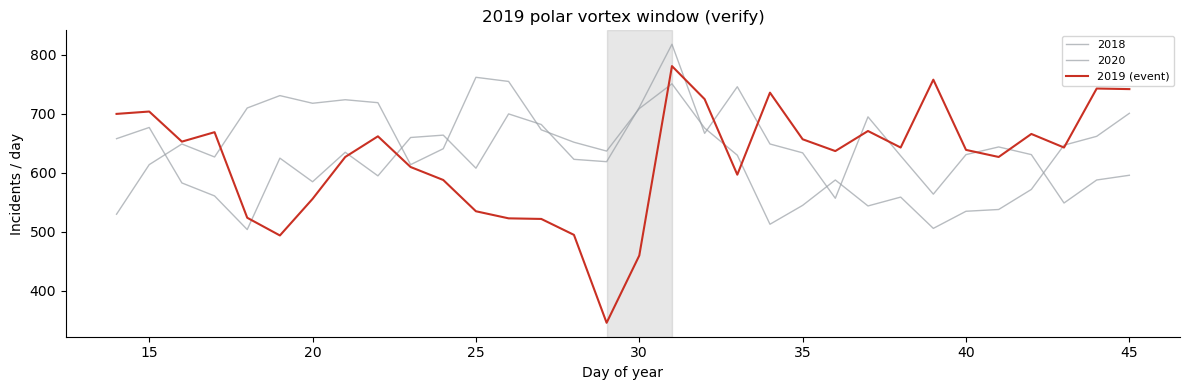

  Lowest day 2019 01-30→02-01: 346
  Same days, baseline years [2018, 2020]: 708
  Deviation: -51.1%


In [14]:
plot_event(2019, [2018, 2020], '2019-01-30', '2019-02-01', '01-15', '02-15',
           '2019 polar vortex window (verify)')
quantify(2019, [2018, 2020], '2019-01-30', '2019-02-01')

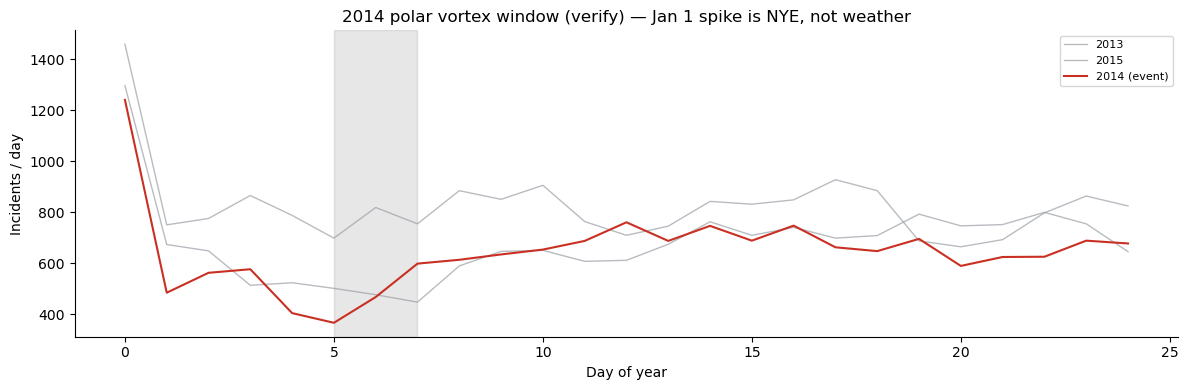

  Lowest day 2014 01-06→01-08: 367
  Same days, baseline years [2013, 2015]: 617
  Deviation: -40.5%


In [15]:
# 2014 window includes Jan 1 — the spike at doy 0 is NYE, not weather.
plot_event(2014, [2013, 2015], '2014-01-06', '2014-01-08', '01-01', '01-25',
           '2014 polar vortex window (verify) — Jan 1 spike is NYE, not weather')
quantify(2014, [2013, 2015], '2014-01-06', '2014-01-08')

**Verdict (fill in after running):**

If all three events show a 15–30% drop on the coldest day against the adjacent-year baseline, the recurring-dip story is real but small. Visually compelling when stacked side-by-side; not on its own a headline.

**Probable small side panel.** Could be combined with a 'weather effects' angle if there's room.

## 6. Chicago municipal elections — incumbent vs open race

Replaces the earlier federal-election hypothesis. Chicago municipal elections happen in **late February** (first round), with an April runoff if no candidate clears 50%.

Hypothesis: in election years where an **incumbent mayor** is on the ballot, reported crime in the January–February run-up dips **below the normal winter floor**, while open races do not. Possible mechanisms (not testable in this notebook): softer enforcement, reporting suppression, deployment patterns.

Test group (incumbent on ballot — **verify all dates**):
- 2015-02-24 — Emanuel running for re-election
- 2023-02-28 — Lightfoot running for re-election

Control group (open race, no incumbent — **verify all dates**):
- 2011-02-22 — open race (Daley did not seek re-election)
- 2019-02-26 — open race (Emanuel did not seek re-election)

Optional extension I could not confirm: 2003-02-25 and 2007-02-27 Daley re-elections. Please verify the dates and that he was the registered incumbent both times before adding them — I left them out rather than guess.

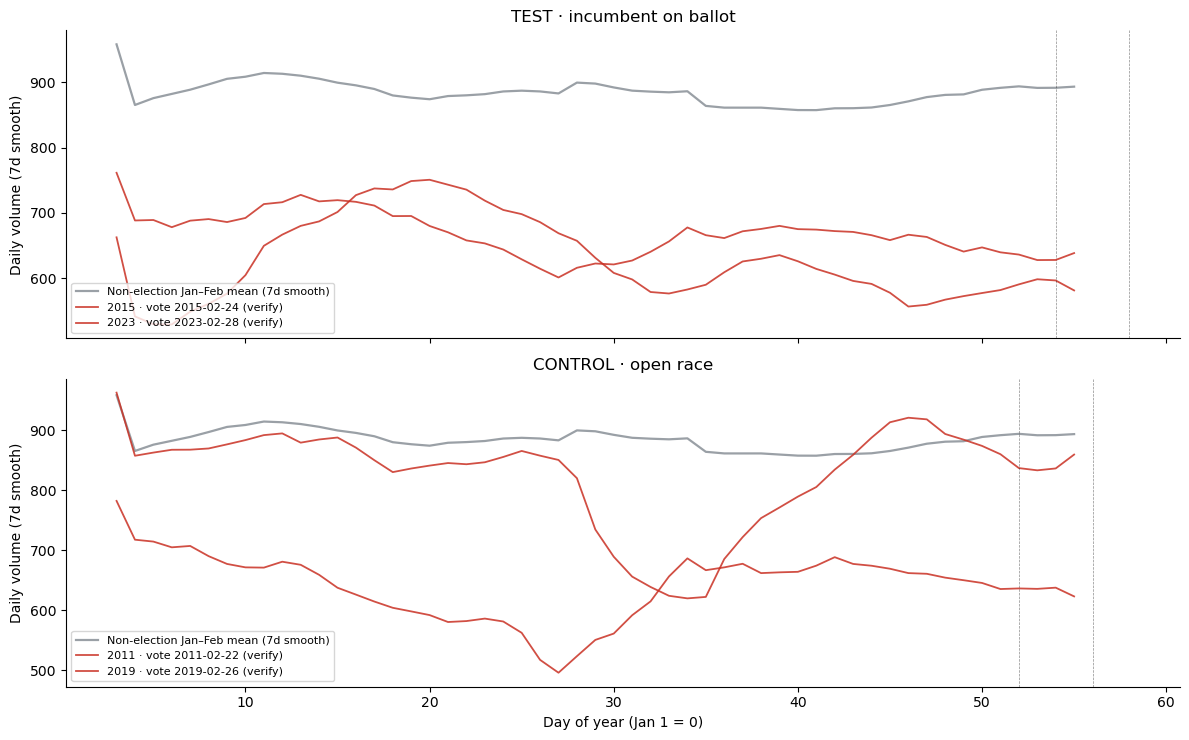

In [16]:
test_dates = {2015: '2015-02-24', 2023: '2023-02-28'}
control_dates = {2011: '2011-02-22', 2019: '2019-02-26'}
election_years = set(test_dates) | set(control_dates)

# Build the non-election Jan-Feb baseline curve, averaged per day-of-year,
# 7-day smoothed for readability.
baseline_pieces = []
for y in range(2001, 2024):
    if y in election_years:
        continue
    w = daily.loc[f'{y}-01-01':f'{y}-02-28'].copy()
    w['doy'] = (w.index - pd.Timestamp(f'{y}-01-01')).days
    baseline_pieces.append(w[['n', 'doy']])
baseline_long = pd.concat(baseline_pieces)
baseline_curve = baseline_long.groupby('doy')['n'].mean().rolling(7, center=True).mean()

fig, axes = plt.subplots(2, 1, figsize=(12, 7.5), sharex=True)
for ax, group, title in [(axes[0], test_dates,    'TEST · incumbent on ballot'),
                          (axes[1], control_dates, 'CONTROL · open race')]:
    ax.plot(baseline_curve.index, baseline_curve.values,
            color='#9aa0a6', lw=1.6, label='Non-election Jan–Feb mean (7d smooth)')
    for y, d in group.items():
        w = daily.loc[f'{y}-01-01':f'{y}-02-28'].copy()
        w['doy'] = (w.index - pd.Timestamp(f'{y}-01-01')).days
        smooth = w['n'].rolling(7, center=True).mean()
        ax.plot(w['doy'].values, smooth.values,
                color='#c93023', alpha=0.85, lw=1.3, label=f'{y} · vote {d} (verify)')
        ax.axvline((pd.Timestamp(d) - pd.Timestamp(f'{y}-01-01')).days,
                   color='#1a1a1a', lw=0.5, ls='--', alpha=0.5)
    ax.set_title(title)
    ax.set_ylabel('Daily volume (7d smooth)')
    ax.legend(fontsize=8, loc='lower left')
axes[1].set_xlabel('Day of year (Jan 1 = 0)')
plt.tight_layout()

In [17]:
# Quantify the 10-day pre-vote window per election, expressed as % deviation
# from the non-election baseline curve for the same days-of-year.
PRE_DAYS = 10

def pre_vote_actual(year, date_str):
    end = pd.Timestamp(date_str)
    start = end - pd.Timedelta(days=PRE_DAYS)
    return daily.loc[start:end - pd.Timedelta(days=1)]['n'].mean()

def pre_vote_baseline(date_str):
    end_doy = (pd.Timestamp(date_str) - pd.Timestamp(f'{pd.Timestamp(date_str).year}-01-01')).days
    start_doy = end_doy - PRE_DAYS
    same_window = baseline_long[(baseline_long['doy'] >= start_doy) & (baseline_long['doy'] < end_doy)]
    return same_window['n'].mean()

print(f'{PRE_DAYS}-day pre-vote windows · % deviation from non-election baseline (verify dates)')
print()
for label, group in [('TEST   (incumbent)', test_dates),
                      ('CTRL   (open race)', control_dates)]:
    for y, d in group.items():
        actual = pre_vote_actual(y, d)
        base = pre_vote_baseline(d)
        pct = (actual - base) / base * 100
        print(f'  {label} · {y}  vote {d}  '
              f'{actual:>6,.0f}/day  vs baseline {base:>6,.0f}/day  → {pct:+.1f}%')

10-day pre-vote windows · % deviation from non-election baseline (verify dates)

  TEST   (incumbent) · 2015  vote 2015-02-24     573/day  vs baseline    884/day  → -35.2%
  TEST   (incumbent) · 2023  vote 2023-02-28     643/day  vs baseline    890/day  → -27.7%
  CTRL   (open race) · 2011  vote 2011-02-22     874/day  vs baseline    873/day  → +0.1%
  CTRL   (open race) · 2019  vote 2019-02-26     634/day  vs baseline    886/day  → -28.4%


**Verdict (frank):**

With only **two test cases and two controls**, this is suggestive at best. Even if the test group dips meaningfully below baseline while controls track baseline, that is N=2 vs N=2 — not enough to call causation, and not nearly enough for a Bonferroni correction across all the hypotheses in this notebook.

Additionally: reported crime is also reported policing. A politically-motivated dip can come from enforcement intensity or report-taking, not from real behaviour change. The dataset cannot distinguish those.

**Recommendation:** keep only if the % column above shows clear test-vs-control separation (test all negative, control near zero). Otherwise drop entirely — a noisy null result with N=2 is weak journalism. If kept, frame it as a *question* ("do incumbent mayoral races track lower winter crime?"), never as an answer.

## 7. Breakdown by primary type (general overview)

Kept for context: which types dominate volume and which ones might respond to specific events.

In [18]:
type_totals = df['type'].value_counts()
print('top 8:', type_totals.head(8).index.tolist())
print()
print(type_totals.head(15))

top 8: ['THEFT', 'BATTERY', 'CRIMINAL DAMAGE', 'NARCOTICS', 'ASSAULT', 'OTHER OFFENSE', 'BURGLARY', 'MOTOR VEHICLE THEFT']

type
THEFT                         1805649
BATTERY                       1548510
CRIMINAL DAMAGE                966455
NARCOTICS                      766021
ASSAULT                        571002
OTHER OFFENSE                  530705
BURGLARY                       448982
MOTOR VEHICLE THEFT            436880
DECEPTIVE PRACTICE             393319
ROBBERY                        316212
CRIMINAL TRESPASS              228533
WEAPONS VIOLATION              126357
PROSTITUTION                    70469
OFFENSE INVOLVING CHILDREN      61022
PUBLIC PEACE VIOLATION          55112
Name: count, dtype: int64


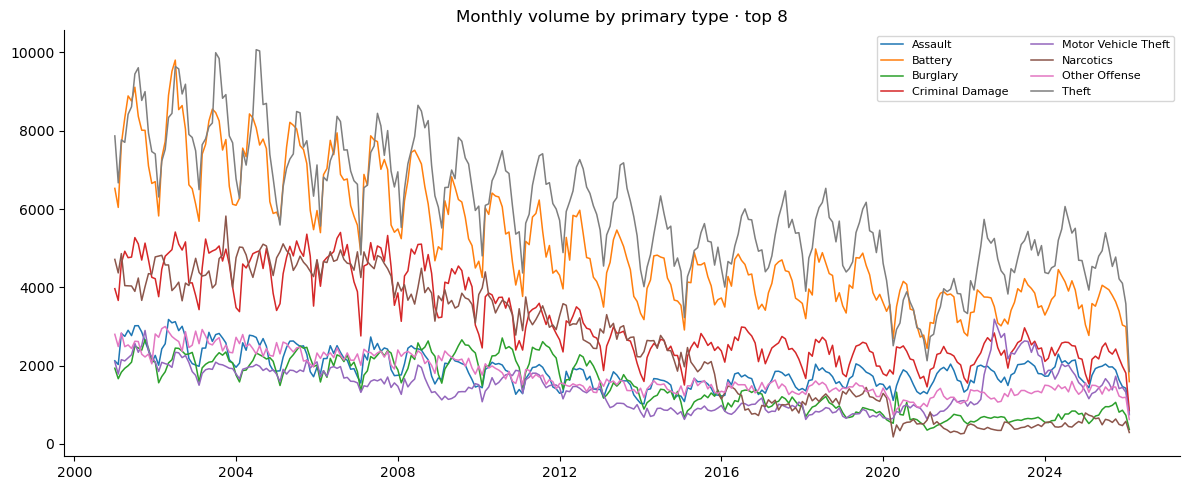

In [19]:
top = type_totals.head(8).index.tolist()
monthly_by_type = (
    df[df['type'].isin(top)]
    .set_index('date')
    .groupby('type', observed=True)
    .resample('MS')
    .size()
    .unstack(level=0)
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(12, 5))
for t in monthly_by_type.columns:
    ax.plot(monthly_by_type.index, monthly_by_type[t], lw=1.1, label=t.title())
ax.set_title('Monthly volume by primary type · top 8')
ax.legend(ncol=2, fontsize=8, loc='upper right')
plt.tight_layout()

## Notes for next steps

Fill in once the cells above have actually been run.

| Section | Effect size (fill in) | Keeper? |
| --- | --- | --- |
| 2. COVID lockdown | % drop vs 2018–19 baseline = | |
| 3. Floyd spike | % vs pre-baseline = | |
| 4. Laquan arrest break | Δpp on arrest rate = ; Δ% on volume = | |
| 5. Blizzards / vortex | % drops (2011 / 2019 / 2014) = | |
| 6. Municipal elections | test % vs control % = | |

Open todos:
- [ ] Verify every event date marked `(verify)` against a primary source
- [ ] Confirm Chicago 2003 / 2007 municipal election dates and incumbent status; add to test group if usable
- [ ] Pick the 3 stories to publish in the Insights tab (likely COVID + Laquan + one of Floyd / blizzards / elections)
- [ ] Define which aggregates to ship: probably `daily_volume.json` (date, n, arrests) + a small per-event slice